In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [123]:
df=pd.read_csv("/content/Metro_Interstate_Traffic_Volume.csv")
df.head()


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [124]:
#no. of rows and columns
df.shape

(48204, 9)

In [125]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [127]:
#summary statistics
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


Finding missing values

In [128]:
df.isnull().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [129]:
#percentage missing
(df.isnull().sum()/len(df))*100

,0
holiday,99.873454
temp,0.000000
rain_1h,0.000000
snow_1h,0.000000
clouds_all,0.000000
weather_main,0.000000
weather_description,0.000000
date_time,0.000000
traffic_volume,0.000000


Duplicate rows: It is important to remove duplicate rows so that the average doesn't become biased

In [130]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

Trafic vokume distribution plot

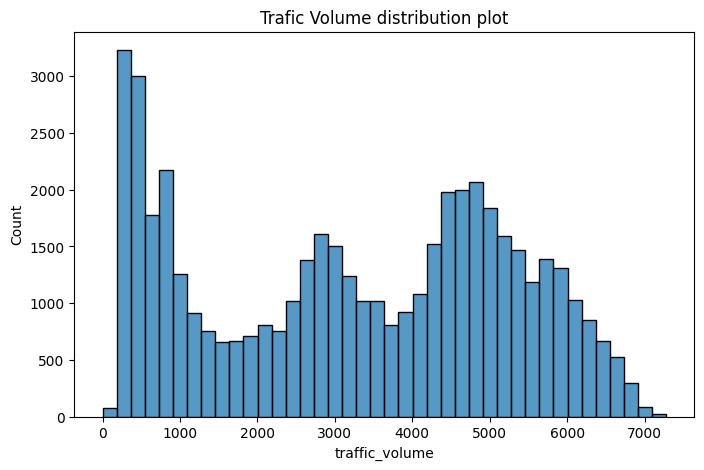

In [131]:
plt.figure(figsize=(8,5))
sns.histplot(df["traffic_volume"],bins=40)
plt.title("Trafic Volume distribution plot")
plt.show()

Correlation heatmap:

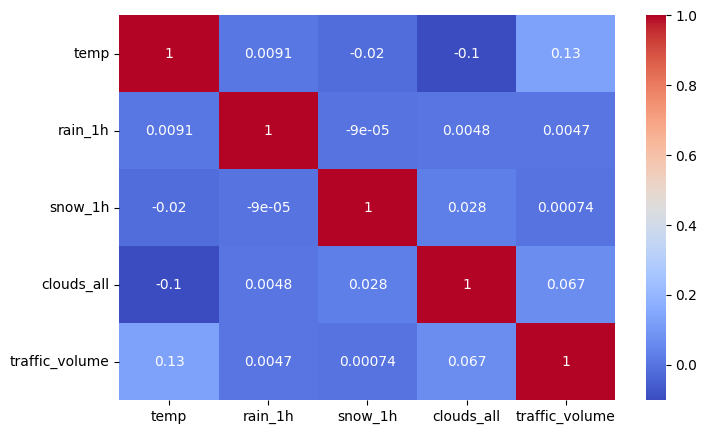

In [132]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")
plt.show()

Boxplot:
To find any extreme points in the dataset. It shows us the numerical features of the dataset

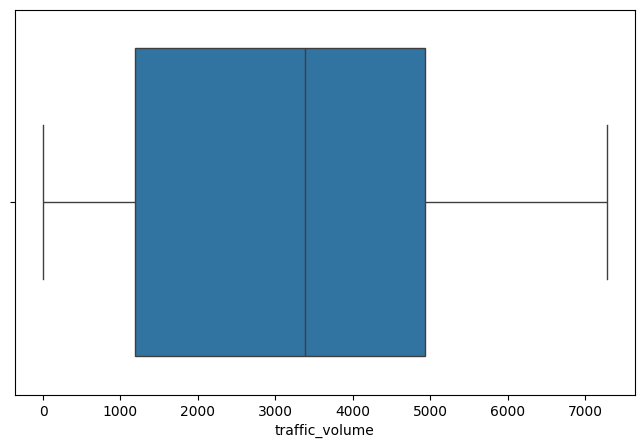

In [133]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["traffic_volume"])
plt.show()

Handling missing values

In [134]:
df["holiday"]=df["holiday"].fillna("None")
#checking again
df.isnull().sum()

,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


Feature Engineering: Creating better features from data to make it more relevant so that the model can learn better. For example, 2012-10-02 09:00:00 this is just a random text for the computer, random forest does not know how to interpret it. But we know that Tuesday 9 am does affect the traffic volume compared to Sunday 6 pm

In [135]:
df["date_time"]=pd.to_datetime(df["date_time"])
#extract
df["hour"]=df["date_time"].dt.hour
df["month"]=df["date_time"].dt.month
df["day"]=df["date_time"].dt.day
df["weekday"]=df["date_time"].dt.weekday
df["is_weekend"]=(df["weekday"]>=5).astype(int)
#dropping original name
df.drop("date_time",axis=1,inplace=True)

importing sklearn,models and metrics

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



Encoding and Train test split

In [137]:
x=df.drop("traffic_volume",axis=1)
y=df["traffic_volume"]

In [138]:
#categorical columns
cat_cols=["holiday","weather_main","weather_description"]
#numerical columns
num_cols=x.select_dtypes(include=np.number).columns

In [139]:
#one hot encoder puts numerical values to string ones
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(handle_unknown="ignore"),
         cat_cols),

        ("num",
         "passthrough",
         num_cols)
    ]
)

In [140]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)


RANDOM FOREST

In [142]:
rf=Pipeline([("preprocessor",preprocessor),
 ("model",RandomForestRegressor(n_estimators=50,n_jobs=1,random_state=42))])
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)

In [145]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest: ")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 :", rf_r2)

Random Forest: 
MAE : 217.34388462336585
RMSE : 379.1963597329173
R2 : 0.9640338790133073


In [ ]:
ADABOOST

In [149]:
ada=Pipeline([("preprocessor",preprocessor),
("model",AdaBoostRegressor(n_estimators=50,random_state=42))])
ada.fit(x_train,y_train)
ada_pred=ada.predict(x_test)

In [154]:
ada_mae=mean_absolute_error(y_test,ada_pred)
ada_mse=mean_squared_error(y_test,ada_pred)
ada_rmse=np.sqrt(ada_mse)
ada_r2=r2_score(y_test,ada_pred)
print("AdaBoost: ")
print("MAE :", ada_mae)
print("RMSE :", ada_rmse)
print("R2 :", ada_r2)

AdaBoost: 
MAE : 616.8678514046189
RMSE : 826.3564729146558
R2 : 0.8291951695806893


XGBoost

In [156]:
xgb=Pipeline([("preprocessor",preprocessor),
              ("model",XGBRegressor(n_estimators=50,
                                    max_depth=6,
                                    learning_rate=0.1,
                                    random_state=42))])
xgb.fit(x_train,y_train)
xgb_pred=xgb.predict(x_test)

In [158]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_pred)
print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R2 :", xgb_r2)

XGBoost
MAE : 257.8452453613281
RMSE : 423.02897728760854
R2 : 0.955238401889801


COMPARISON TABLE

In [159]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "AdaBoost",
        "XGBoost"
    ],
    "MAE": [
        rf_mae,
        ada_mae,
        xgb_mae
    ],
    "RMSE": [
        rf_rmse,
        ada_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        rf_r2,
        ada_r2,
        xgb_r2
    ]})
comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,217.343885,379.196360,0.964034
1,AdaBoost,616.867851,826.356473,0.829195
2,XGBoost,257.845245,423.028977,0.955238


HENCE RANDOM FOREST IS THE BEST ONE CAUSE Mean Absolute Error and Root Mean Square Errors are the lowest and R2 score is the highest

COMPARISON GRAPH:

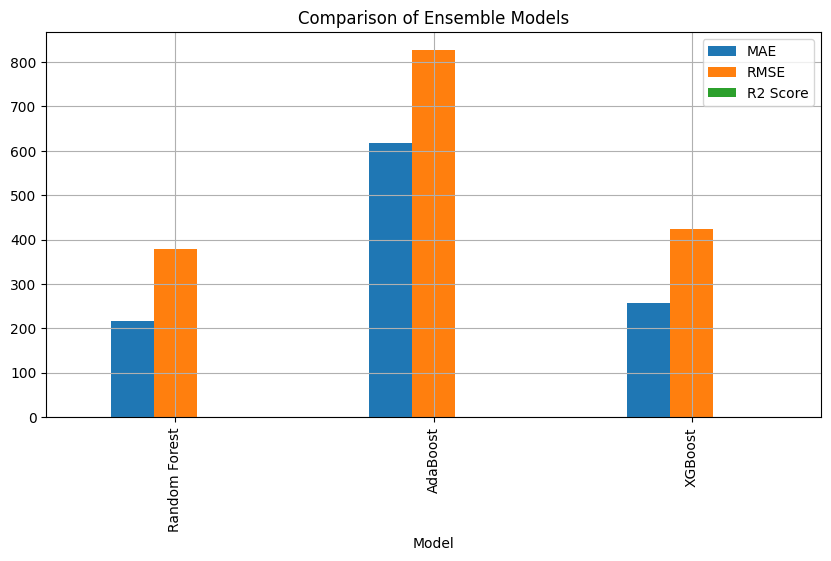

In [161]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,5))
plt.title("Comparison of Ensemble Models")
plt.grid(True)
plt.show()

Actual vs predicted (Best Model)

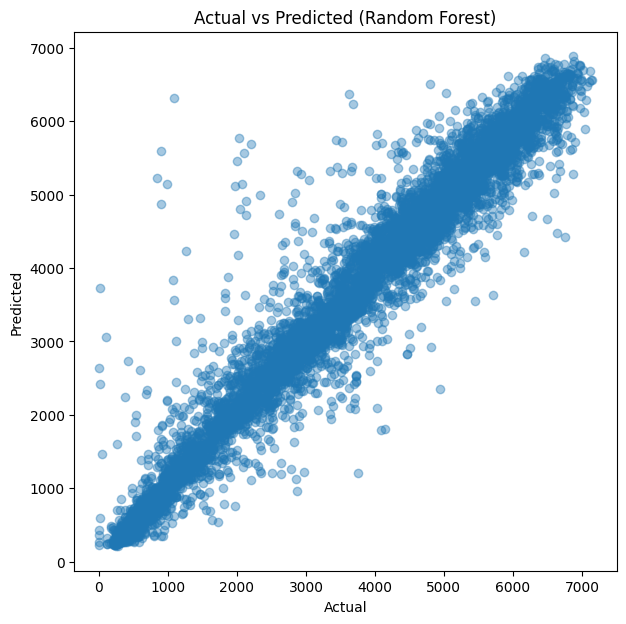

In [163]:
plt.figure(figsize=(7,7))
plt.scatter(y_test,
            rf_pred,
            alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()